1. Load and explore the dataset with Pandas

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


df= pd.read_csv("100Fdataset.csv")    #Load the iris dataset available

In [2]:
print("Shape of dataset: ",df.shape)    #shape of the dataset

Shape of dataset:  (60, 101)


In [3]:
print(df.head())   #top 5 rows

         f1        f2        f3        f4        f5        f6        f7  \
0 -0.227541  2.245819  0.189548  0.771113 -0.093919 -1.165325  1.662969   
1 -1.304655  1.324779 -0.657773  0.149177 -0.589979 -0.716866  8.591600   
2 -1.160870  3.417647 -0.137354 -1.337709 -0.185429  0.002685  1.787482   
3 -0.304939  1.147956 -0.621994  0.274743 -0.959024  0.765498 -5.481604   
4  0.568481  0.787324 -0.305457 -2.144488  0.003376  2.179543  3.780279   

         f8        f9       f10  ...       f92       f93       f94       f95  \
0 -1.546308  1.291678 -0.520648  ...  0.019458 -0.038404 -0.342429  1.234851   
1  1.715756 -2.455125  0.965408  ...  0.587763 -0.700349  0.618029 -1.218973   
2 -0.797143  2.453903  0.038233  ... -0.673623 -0.367229  2.155333  0.955275   
3  1.831555 -0.153456  0.578276  ...  0.951292 -0.788697  0.760782 -0.365229   
4 -0.570626  0.133839  0.554751  ...  0.117376 -0.176512  0.320760 -0.489695   

        f96       f97       f98       f99      f100  target  
0  2.8

In [4]:
print(df.isnull().sum())     #sum of null values

f1        0
f2        0
f3        0
f4        0
f5        0
         ..
f97       0
f98       0
f99       0
f100      0
target    0
Length: 101, dtype: int64


In [7]:
print(df.describe())   #descriptive statistics of the dataset

              f1         f2         f3         f4         f5         f6  \
count  60.000000  60.000000  60.000000  60.000000  60.000000  60.000000   
mean   -0.028935   0.286785  -0.103402   0.087032  -0.135694  -0.146387   
std     0.890323   1.870533   0.915134   1.165175   0.925770   0.863177   
min    -2.549423  -4.930356  -1.616514  -2.194248  -2.222441  -2.111918   
25%    -0.618690  -0.954514  -0.692596  -0.847990  -0.814987  -0.678545   
50%    -0.049624   0.485628  -0.121495   0.074798  -0.192367  -0.232226   
75%     0.526495   1.600100   0.559375   1.166500   0.559807   0.452722   
max     1.501390   3.717837   3.133537   2.630623   1.747376   2.179543   

              f7         f8         f9        f10  ...        f92        f93  \
count  60.000000  60.000000  60.000000  60.000000  ...  60.000000  60.000000   
mean    0.879661  -0.085797  -0.042836   0.155892  ...  -0.105728   0.056013   
std     3.680071   1.112531   1.135752   1.034706  ...   0.925520   0.790548   
min 

In [8]:
print(df['target'].value_counts())     #number of classes in target column

target
0    22
2    20
1    18
Name: count, dtype: int64


In [11]:
print(df['target'].value_counts())   #count for each class

print(df['target'].value_counts(normalize=True) * 100)  # percentage distribution

target
0    22
2    20
1    18
Name: count, dtype: int64
target
0    36.666667
2    33.333333
1    30.000000
Name: proportion, dtype: float64


2. Preprocessing

In [13]:
X = df.drop('target', axis=1)
y = df['target']

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [19]:
print(X_scaled_df.head())

         f1        f2        f3        f4        f5        f6        f7  \
0 -0.224955  1.056152  0.322818  0.592060  0.045506 -1.190412  0.214648   
1 -1.444966  0.559602 -0.610894  0.053785 -0.494851 -0.666483  2.113280   
2 -1.282106  1.687906 -0.037414 -1.233089 -0.054176  0.174160  0.248768   
3 -0.312620  0.464274 -0.571467  0.162461 -0.896851  1.065345 -1.743158   
4  0.676673  0.269850 -0.222656 -1.931342  0.151489  2.717355  0.794848   

         f8        f9       f10  ...       f91       f92       f93       f94  \
0 -1.323860  1.184921 -0.659365  ...  0.653186  0.136401 -0.120440 -0.094398   
1  1.632994 -2.141881  0.788966  ...  0.629899  0.755622 -0.964830  0.910978   
2 -0.644790  2.216865 -0.114671  ...  0.539888 -0.618774 -0.539895  2.520179   
3  1.737959 -0.098220  0.411661  ... -2.278909  1.151721 -1.077528  1.060408   
4 -0.439466  0.156870  0.388734  ...  0.625118  0.243093 -0.296614  0.599807   

        f95       f96       f97       f98       f99      f100  
0  1

In [20]:
print(X_scaled_df.describe())

                 f1            f2            f3            f4            f5  \
count  6.000000e+01  6.000000e+01  6.000000e+01  6.000000e+01  6.000000e+01   
mean   7.401487e-18  2.960595e-17 -2.960595e-17 -4.348374e-17 -2.035409e-17   
std    1.008439e+00  1.008439e+00  1.008439e+00  1.008439e+00  1.008439e+00   
min   -2.854873e+00 -2.812658e+00 -1.667385e+00 -1.974409e+00 -2.273088e+00   
25%   -6.679962e-01 -6.692071e-01 -6.492677e-01 -8.092453e-01 -7.399520e-01   
50%   -2.343423e-02  1.072001e-01 -1.993789e-02 -1.058887e-02 -6.173373e-02   
75%    6.291168e-01  7.080330e-01  7.303515e-01  9.342606e-01  7.576086e-01   
max    1.733348e+00  1.849745e+00  3.566969e+00  2.201434e+00  2.051225e+00   

                 f6            f7            f8            f9           f10  \
count  6.000000e+01  6.000000e+01  6.000000e+01  6.000000e+01  6.000000e+01   
mean   4.533411e-17 -4.625929e-18  1.850372e-18  3.446317e-17 -1.480297e-17   
std    1.008439e+00  1.008439e+00  1.008439e+00  1.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
y_train_encoded = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_test_encoded = tf.keras.utils.to_categorical(y_test, num_classes=3)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (48, 100)
Test set shape: (12, 100)


In [28]:
#ANN architecture
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(5, activation='relu'),  # First hidden layer
    layers.Dense(5, activation='relu'),                      # Second hidden layer
    layers.Dense(3, activation='softmax')                    # Output layer
])

model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 5)              │           505 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 553 (2.16 KB)

 Trainable params: 553 (2.16 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Train the model
history = model.fit(
    X_train, y_train_encoded,
    epochs=50,
    batch_size=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7853 - loss: 0.6438 - val_accuracy: 0.3000 - val_loss: 1.4454
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7486 - loss: 0.5959 - val_accuracy: 0.3000 - val_loss: 1.4517
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7825 - loss: 0.6581 - val_accuracy: 0.3000 - val_loss: 1.4569
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7858 - loss: 0.6778 - val_accuracy: 0.3000 - val_loss: 1.4605
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8125 - loss: 0.5961 - val_accuracy: 0.3000 - val_loss: 1.4643
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7696 - loss: 0.6237 - val_accuracy: 0.3000 - val_loss: 1.4684
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7968 - loss: 0.6483 - val_accuracy: 0.3000 - val_loss: 1.4723
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8102 - loss: 0.6110 - val_accuracy: 0.3000 - val_loss: 1.4761


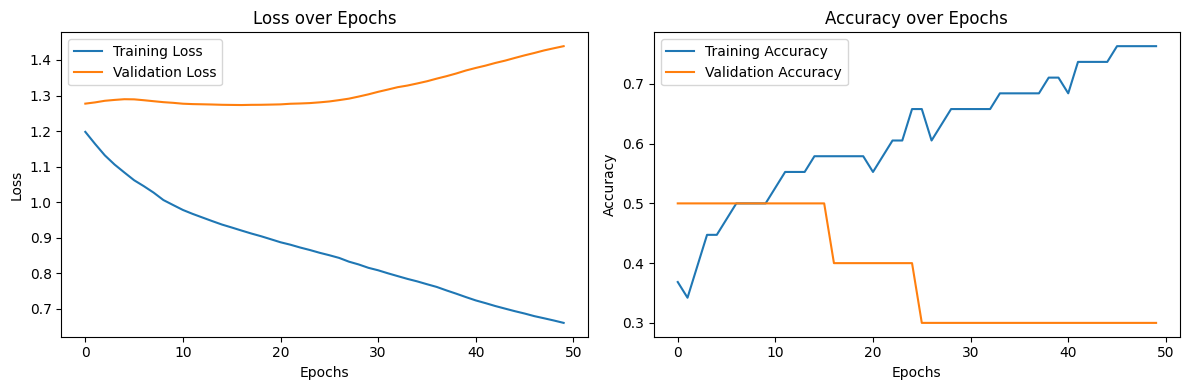

In [31]:
# Plot loss over epochs
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [33]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test_encoded, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

Test Accuracy: 0.3333
Test Loss: 1.4793
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         4
           1       0.50      0.50      0.50         4
           2       0.00      0.00      0.00         4

    accuracy                           0.33        12
   macro avg       0.28      0.33      0.30        12
weighted avg       0.28      0.33      0.30        12



In [37]:
# K-Fold Cross-Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
cv_precision = []
cv_recall = []
cv_f1 = []

for train_idx, val_idx in kfold.split(X_scaled, y):
    # Split data
    X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    # One-hot encoding
    y_train_fold_encoded = tf.keras.utils.to_categorical(y_train_fold, num_classes=3)
    y_val_fold_encoded = tf.keras.utils.to_categorical(y_val_fold, num_classes=3)

    # Create and train model
    model_cv = keras.Sequential([
        layers.Dense(10, activation='relu', input_shape=(100,)),
        layers.Dense(5, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model_cv.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Train with early stopping to prevent overfitting
    history_cv = model_cv.fit(
        X_train_fold, y_train_fold_encoded,
        epochs=50, batch_size=10, verbose=0, validation_split=0.2
    )

    # Evaluate
    val_loss, val_accuracy = model_cv.evaluate(X_val_fold, y_val_fold_encoded, verbose=0)
    cv_scores.append(val_accuracy)

    # Make predictions for metrics
    y_pred_fold = model_cv.predict(X_val_fold, verbose=0)
    y_pred_classes_fold = np.argmax(y_pred_fold, axis=1)

    report = classification_report(y_val_fold, y_pred_classes_fold, output_dict=True)
    cv_precision.append(report['weighted avg']['precision'])
    cv_recall.append(report['weighted avg']['recall'])
    cv_f1.append(report['weighted avg']['f1-score'])

print(f"Cross-Validation Results:")
print(f"Average Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
print(f"Average Precision: {np.mean(cv_precision):.4f}")
print(f"Average Recall: {np.mean(cv_recall):.4f}")
print(f"Average F1-Score: {np.mean(cv_f1):.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Cross-Validation Results:
Average Accuracy: 0.3500 (+/- 0.1616)
Average Precision: 0.3415
Average Recall: 0.3500
Average F1-Score: 0.3327
